In [3]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Load data
df = pd.read_csv(r"C:\Users\Visesha\Desktop\GitHub\netflix-data-analysis\data\netflix_titles.csv\netflix_titles.csv")

#Display first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
#Dataset Understanding

In [4]:
df.shape

(8807, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [ ]:
#Data Cleaning

In [8]:
#removing null values
df.dropna(subset=['director','country'], inplace = True)

In [12]:
#Convert Date Column
df['date_added'] = pd.to_datetime(['date_added'], errors='coerce')

ValueError: Length of values (1) does not match length of index (5751)

In [15]:
df['date_added'].isnull().sum()

np.int64(0)

In [14]:
df.dropna(subset=['date_added'], inplace=True)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5751 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       5751 non-null   object        
 1   type          5751 non-null   object        
 2   title         5751 non-null   object        
 3   director      5751 non-null   object        
 4   cast          5336 non-null   object        
 5   country       5751 non-null   object        
 6   date_added    5746 non-null   datetime64[ns]
 7   release_year  5751 non-null   int64         
 8   rating        5750 non-null   object        
 9   duration      5748 non-null   object        
 10  listed_in     5751 non-null   object        
 11  description   5751 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 584.1+ KB


In [17]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [ ]:
#Analysis Questions

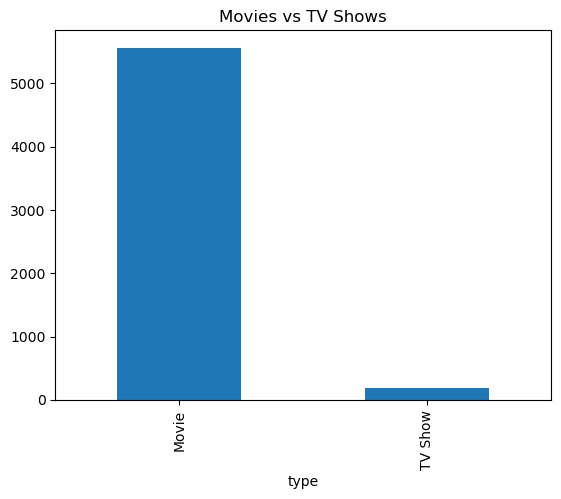

In [38]:
#1. Movies vs TV Shows
df['type'].value_counts().plot(kind = 'bar')

plt.title("Movies vs TV Shows")
plt.savefig(r'C:\Users\Visesha\Desktop\GitHub\netflix-data-analysis\images\movies_vs_tvshows.png', dpi=300, bbox_inches='tight')
plt.show()

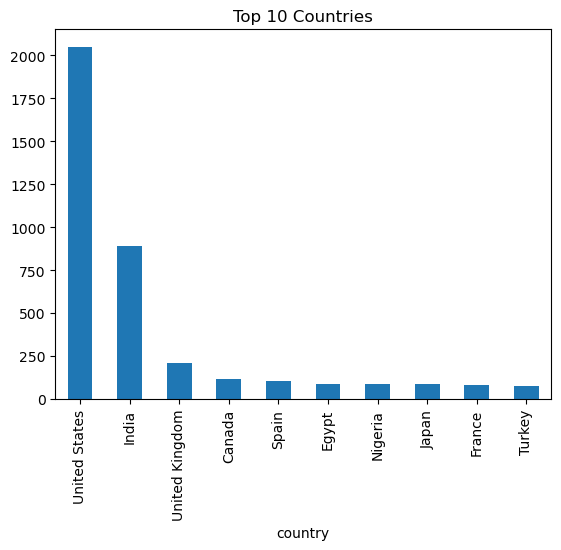

In [37]:
#2. Top 10 Countries
top_countries = df['country'].value_counts().head(10)
top_countries.plot(kind = 'bar')

plt.title('Top 10 Countries')
plt.savefig(r'C:\Users\Visesha\Desktop\GitHub\netflix-data-analysis\images\top_countries.png', dpi=300, bbox_inches='tight')
plt.show()


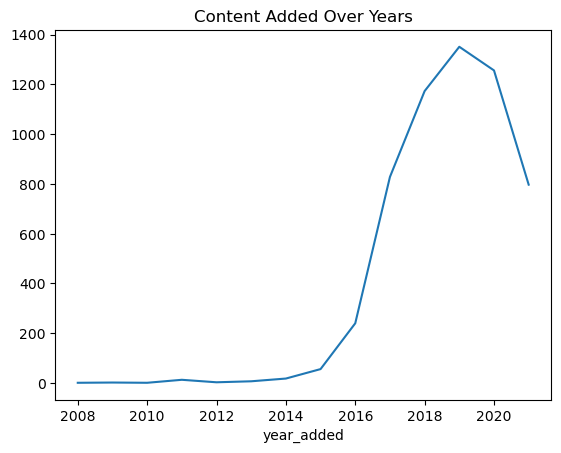

In [22]:
#3. Content Added Over Years
df['year_added'] = df['date_added'].dt.year

df['year_added'].value_counts().sort_index().plot()

plt.title('Content Added Over Years')
plt.show()

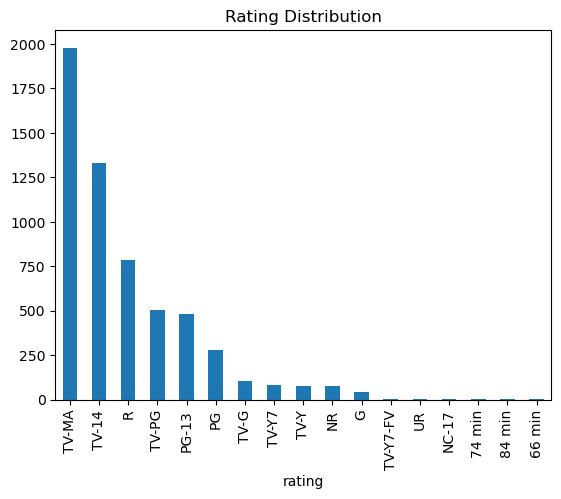

In [36]:
#4. Most Popular Ratings
df['rating'].value_counts().plot(kind = 'bar')

plt.title('Rating Distribution')
plt.savefig(r'C:\Users\Visesha\Desktop\GitHub\netflix-data-analysis\images\rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

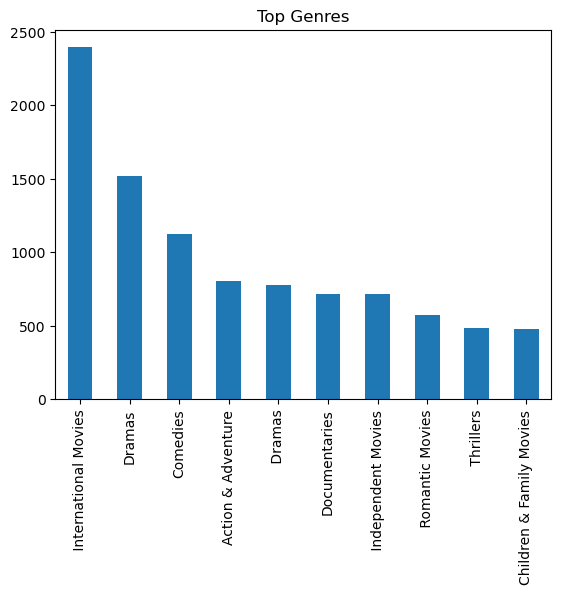

In [35]:
#5. Top Genres
genres = df['listed_in'].str.split(',', expand = True).stack()
genres.value_counts().head(10).plot(kind='bar')

plt.title('Top Genres')

plt.savefig(r'C:\Users\Visesha\Desktop\GitHub\netflix-data-analysis\images\top_genres.png', dpi=300, bbox_inches='tight')
plt.show()